# 🔥 Intel Image Classification — PyTorch CNN

**Dataset:** [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)  
**Framework:** PyTorch  
**Output:** `your_firstname_model.pth` saved to Google Drive  

---

### 📋 Notebook Sections
1. GPU Check & Setup
2. Mount Google Drive
3. Install Dependencies
4. Download Dataset via Kaggle API
5. Data Pipeline (Transforms & DataLoaders)
6. Model Architecture (IntelCNN)
7. Training Loop
8. Evaluation & Plots
9. Save Model & Download

> ⚡ **Runtime:** Go to `Runtime → Change runtime type → T4 GPU` before running.

## 1️⃣ GPU Check & Setup

In [ ]:
import torch

# ── Verify GPU ─────────────────────────────────────────────────
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅  GPU detected : {gpu_name}")
    print(f"    VRAM        : {gpu_mem:.1f} GB")
    print(f"    CUDA version: {torch.version.cuda}")
    DEVICE = torch.device('cuda')
else:
    print("⚠️  No GPU found — running on CPU (will be slow).")
    print("   Go to Runtime → Change runtime type → T4 GPU")
    DEVICE = torch.device('cpu')

print(f"\nPyTorch version : {torch.__version__}")
print(f"Device selected : {DEVICE}")

✅  GPU detected : Tesla T4
    VRAM        : 15.6 GB
    CUDA version: 12.8

PyTorch version : 2.10.0+cu128
Device selected : cuda


## 2️⃣ Mount Google Drive

Models and checkpoints will be saved to `My Drive/intel_classifier/`.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# ── Output directory on Drive ──────────────────────────────────
DRIVE_OUTPUT = '/content/drive/MyDrive/intel_classifier'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print(f"📁  Output directory: {DRIVE_OUTPUT}")

Mounted at /content/drive
📁  Output directory: /content/drive/MyDrive/intel_classifier


## 3️⃣ Install Dependencies

In [ ]:
# torchvision is pre-installed on Colab — just confirm versions
import torchvision
print(f"torchvision : {torchvision.__version__}")

# Install kaggle API for dataset download
!pip install -q kaggle
print("✅  kaggle installed")

torchvision : 0.25.0+cu128
✅  kaggle installed


## 4️⃣ Download Dataset via Kaggle API

### How to get your `kaggle.json`
1. Go to [kaggle.com](https://kaggle.com) → Profile → Settings → **Create New Token**
2. A `kaggle.json` file downloads to your computer
3. Run the cell below — it will prompt you to upload that file

In [ ]:
from google.colab import files
import os, zipfile, shutil

# ── Upload kaggle.json ─────────────────────────────────────────
print("📤  Upload your kaggle.json file:")
uploaded = files.upload()   # triggers a file picker

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅  kaggle.json configured")

📤  Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅  kaggle.json configured


In [ ]:
# ── Download & unzip dataset (~350 MB) ────────────────────────
DATA_DIR = '/content/intel_data'
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d puneet6060/intel-image-classification -p {DATA_DIR} --unzip

# ── Verify structure ───────────────────────────────────────────
for root, dirs, files_list in os.walk(DATA_DIR):
    depth = root.replace(DATA_DIR, '').count(os.sep)
    if depth < 3:
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(root)}/")
        if depth == 2:
            n = len([f for f in files_list if f.endswith(('.jpg','.jpeg','.png'))])
            print(f"{indent}  → {n} images")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:09<00:00, 39.4MB/s]

intel_data/
  seg_test/
    seg_test/
      → 0 images
  seg_train/
    seg_train/
      → 0 images
  seg_pred/
    seg_pred/
      → 7301 images


## 5️⃣ Data Pipeline

**Augmentation strategy (train only):**
- Resize to 170×170 → RandomCrop to 150×150
- RandomHorizontalFlip (p=0.5)
- RandomRotation ±15°
- ColorJitter (brightness, contrast, saturation, hue)
- RandomGrayscale (p=0.05)
- ImageNet normalisation

**Validation split:** 10% of training data

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ── Hyperparameters ────────────────────────────────────────────
IMG_SIZE   = 150
BATCH_SIZE = 64   # larger batch fits well on T4
NUM_WORKERS = 2
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Transforms ────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                            saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

# ── Locate folders ─────────────────────────────────────────────
def find_folder(root, candidates):
    for c in candidates:
        p = os.path.join(root, c)
        if os.path.isdir(p):
            return p
    raise FileNotFoundError(f"Could not find dataset folder in {root}")

train_dir = find_folder(DATA_DIR, ["seg_train/seg_train", "seg_train"])
test_dir  = find_folder(DATA_DIR, ["seg_test/seg_test",  "seg_test"])

# ── Datasets ───────────────────────────────────────────────────
full_train = datasets.ImageFolder(train_dir, transform=train_transform)
test_ds    = datasets.ImageFolder(test_dir,  transform=eval_transform)

val_size   = int(0.1 * len(full_train))
train_size = len(full_train) - val_size
train_sub, val_sub = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
# Apply eval transform to validation subset
val_sub.dataset = copy.deepcopy(full_train)
val_sub.dataset.transform = eval_transform

# ── DataLoaders ────────────────────────────────────────────────
train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_sub,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train samples : {len(train_sub):,}")
print(f"Val   samples : {len(val_sub):,}")
print(f"Test  samples : {len(test_ds):,}")
print(f"Classes       : {full_train.classes}")

Train samples : 12,631
Val   samples : 1,403
Test  samples : 3,000
Classes       : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


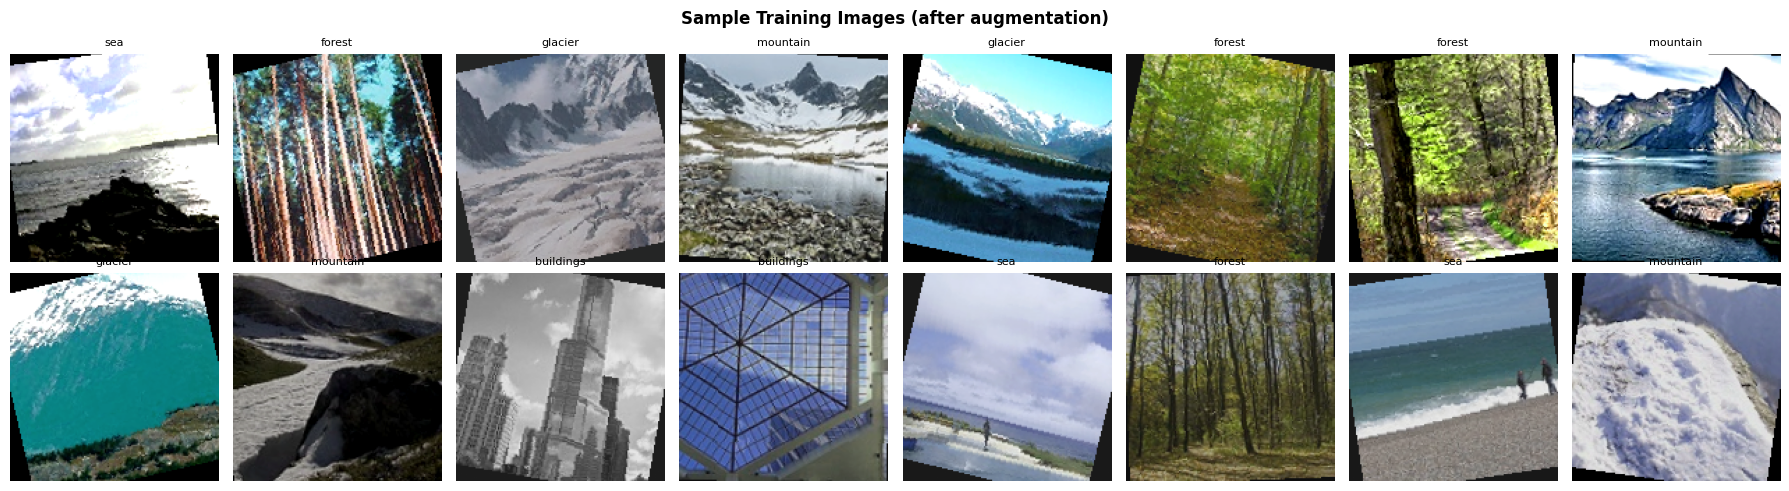

Sample grid saved to Drive.


In [ ]:
# ── Visualise a batch of training images ──────────────────────
def denorm(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flat):
    if i >= 16: break
    img = denorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, 'sample_images.png'), dpi=120)
plt.show()
print("Sample grid saved to Drive.")

## 6️⃣ Model Architecture — IntelCNN

```
Input 150×150×3
 ├─ Stage 1: Conv(32) → Conv(64)  → MaxPool  → 75×75×64
 ├─ Stage 2: Conv(128)→ Conv(128) → MaxPool  → 37×37×128
 ├─ Stage 3: Conv(256)→ Conv(256) → MaxPool  → 18×18×256
 ├─ Stage 4: Conv(512)→ Conv(512) → MaxPool  →  9×9×512
 ├─ GlobalAveragePooling          → 512
 ├─ Dense(256, ReLU)
 ├─ Dropout(0.4)
 └─ Dense(6, Softmax)
```
Each Conv block: **Conv2D → BatchNorm → ReLU**  
Weights init: Kaiming Normal (conv), Xavier Uniform (linear)

In [ ]:
import torch.nn as nn

class ConvBlock(nn.Module):
    """Conv2D → BatchNorm → ReLU (→ optional MaxPool)."""
    def __init__(self, in_ch, out_ch, pool=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class IntelCNN(nn.Module):
    """6-class Intel scene classifier."""
    def __init__(self, num_classes=6):
        super().__init__()
        self.stage1 = nn.Sequential(ConvBlock(3, 32), ConvBlock(32, 64, pool=True))
        self.stage2 = nn.Sequential(ConvBlock(64, 128), ConvBlock(128, 128, pool=True))
        self.stage3 = nn.Sequential(ConvBlock(128, 256), ConvBlock(256, 256, pool=True))
        self.stage4 = nn.Sequential(ConvBlock(256, 512), ConvBlock(512, 512, pool=True))
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.gap(x)
        return self.classifier(x)


# ── Instantiate & inspect ──────────────────────────────────────
model = IntelCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model        : IntelCNN")
print(f"Parameters   : {total_params:,}")
print(f"Device       : {next(model.parameters()).device}")

# Quick forward-pass sanity check
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape : {out.shape}   (batch=2, classes={NUM_CLASSES}) ✅")

Model        : IntelCNN
Parameters   : 4,800,806
Device       : cuda:0
Output shape : torch.Size([2, 6])   (batch=2, classes=6) ✅


## 7️⃣ Training

| Setting | Value |
|---------|-------|
| Optimiser | AdamW (weight_decay=1e-4) |
| Loss | CrossEntropy + label smoothing 0.1 |
| LR schedule | Cosine Annealing → 1e-6 |
| Epochs | 25 |
| Best-model | Saved on highest val accuracy |

In [ ]:
import time
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── Config ─────────────────────────────────────────────────────
EPOCHS = 25
LR     = 1e-3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ── Helpers ────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100. * correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, 100. * correct / total

# ── Training loop ──────────────────────────────────────────────
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc   = 0.0
best_wts       = copy.deepcopy(model.state_dict())
CKPT_PATH      = os.path.join(DRIVE_OUTPUT, 'best_checkpoint.pth')

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'Time':>5}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc = eval_epoch(model, val_loader,   criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    marker = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_wts     = copy.deepcopy(model.state_dict())
        torch.save({'model_state_dict': best_wts,
                    'optimizer_state_dict': optimizer.state_dict(),
                    'epoch': epoch, 'val_acc': best_val_acc},
                   CKPT_PATH)
        marker = '  ✓ best'

    elapsed = time.time() - t0
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2f}%  "
          f"{vl_loss:>8.4f}  {vl_acc:>6.2f}%  {elapsed:>4.0f}s{marker}")

print(f"\n🏆  Best val acc : {best_val_acc:.2f}%")

Epoch  Train Loss  Train Acc  Val Loss  Val Acc   Time
-----------------------------------------------------------------
    1      1.2812     55.10%    1.1292   64.50%    76s  ✓ best
    2      1.0315     70.68%    1.2936   61.72%    77s
    3      0.9393     75.85%    1.0486   68.14%    76s  ✓ best
    4      0.8825     79.27%    0.7668   83.75%    77s  ✓ best
    5      0.8525     80.83%    0.7773   83.75%    76s
    6      0.8319     81.79%    0.7923   83.54%    75s
    7      0.8065     83.07%    0.9785   73.98%    75s
    8      0.7847     83.90%    0.9539   72.84%    75s
    9      0.7705     84.87%    0.7797   83.39%    75s
   10      0.7547     85.62%    0.7645   85.32%    76s  ✓ best
   11      0.7385     86.37%    0.8778   77.55%    76s
   12      0.7318     86.51%    0.7868   83.68%    89s
   13      0.7219     87.24%    0.8210   80.68%    78s
   14      0.7144     87.65%    0.7582   84.68%    77s
   15      0.6991     88.30%    0.7557   84.75%    77s
   16      0.6975     

## 8️⃣ Evaluation & Plots

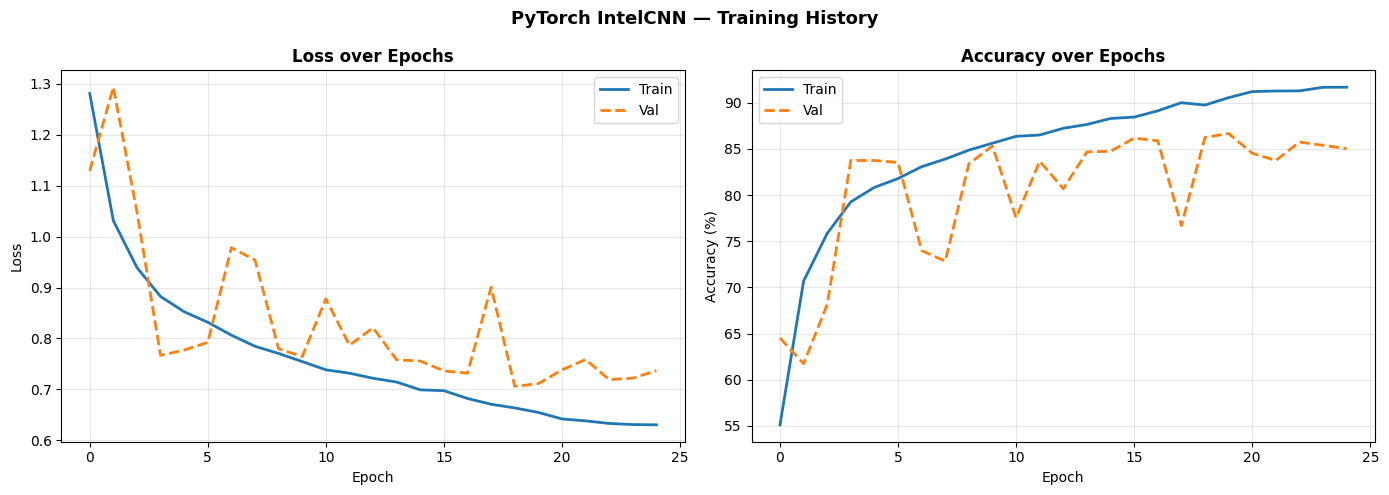

Plot saved → /content/drive/MyDrive/intel_classifier/pytorch_training_history.png


In [ ]:
# ── Training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Loss over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('PyTorch IntelCNN — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plot_path = os.path.join(DRIVE_OUTPUT, 'pytorch_training_history.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved → {plot_path}")

In [ ]:
# ── Test set evaluation ────────────────────────────────────────
model.load_state_dict(best_wts)
test_loss, test_acc = eval_epoch(model, test_loader, criterion, DEVICE)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")

Test Loss     : 0.7048
Test Accuracy : 86.63%


              precision    recall  f1-score   support

   buildings       0.79      0.92      0.85       437
      forest       0.98      0.97      0.98       474
     glacier       0.87      0.80      0.84       553
    mountain       0.87      0.75      0.80       525
         sea       0.79      0.95      0.86       510
      street       0.92      0.83      0.88       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



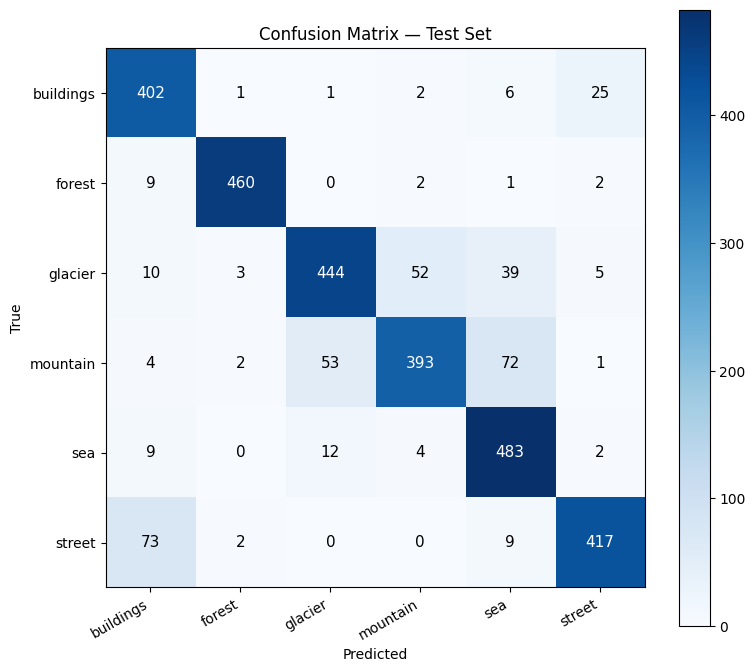

Confusion matrix saved → /content/drive/MyDrive/intel_classifier/pytorch_confusion_matrix.png


In [ ]:
# ── Confusion matrix ───────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import itertools

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       xlabel='Predicted', ylabel='True',
       title='Confusion Matrix — Test Set')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black', fontsize=11)
plt.tight_layout()
cm_path = os.path.join(DRIVE_OUTPUT, 'pytorch_confusion_matrix.png')
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Confusion matrix saved → {cm_path}")

## 9️⃣ Save Model & Download

The model is saved in two ways:
- **Google Drive** → `My Drive/intel_classifier/your_firstname_model.pth`  
- **Direct download** → triggers a browser download for local use

In [ ]:
# ── Save final model to Google Drive ──────────────────────────
SAVE_PATH = os.path.join(DRIVE_OUTPUT, 'intel_model.pth')

torch.save({
    'model_state_dict':     best_wts,
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names':          CLASS_NAMES,
    'img_size':             IMG_SIZE,
    'num_classes':          NUM_CLASSES,
    'best_val_acc':         best_val_acc,
    'test_acc':             test_acc,
    'history':              history,
    'architecture':         'IntelCNN',
}, SAVE_PATH)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
print(f"✅  Model saved to Drive → {SAVE_PATH}")
print(f"    File size : {size_mb:.1f} MB")
print(f"    Val  acc  : {best_val_acc:.2f}%")
print(f"    Test acc  : {test_acc:.2f}%")

✅  Model saved to Drive → /content/drive/MyDrive/intel_classifier/intel_model.pth
    File size : 57.7 MB
    Val  acc  : 86.67%
    Test acc  : 86.63%


In [ ]:
# ── Download to local machine ──────────────────────────────────
# This will trigger a browser download dialog
from google.colab import files
files.download(SAVE_PATH)
print("📥  Download started — save to your project's models/ folder")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥  Download started — save to your project's models/ folder


## 🏠 Loading the Model Locally

After downloading `your_firstname_model.pth`, place it in your Flask project:

```
flask_app/
  models/
    your_firstname_model.pth   ← here
```

The Flask `app.py` loads it automatically. You can also load it manually:

```python
import torch
from pytorch_model import IntelCNN

ckpt  = torch.load('models/your_firstname_model.pth', map_location='cpu')
model = IntelCNN(num_classes=6)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print('Classes :', ckpt['class_names'])
print('Val acc :', ckpt['best_val_acc'])
```